<a href="https://colab.research.google.com/github/Inakshihansika/inakshihansika.github.io/blob/main/Python%20DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import yfinance as yf
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

tables = soup.find_all("table")

tesla_revenue = pd.DataFrame(columns=["Date","Revenue"])

for table in tables:
    if "Tesla Quarterly Revenue" in table.text:
        for row in table.find("tbody").find_all("tr"):
            cols = row.find_all("td")
            if len(cols)==2:
                tesla_revenue.loc[len(tesla_revenue)] = [cols[0].text, cols[1].text]

tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",|\$","",regex=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"]!=""]
tesla_revenue.dropna(inplace=True)

tesla_revenue.tail()

<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1102/1697358482.py:21: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(",|\$","",regex=True)


,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


In [5]:
gme = yf.Ticker("GME")

gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)

gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


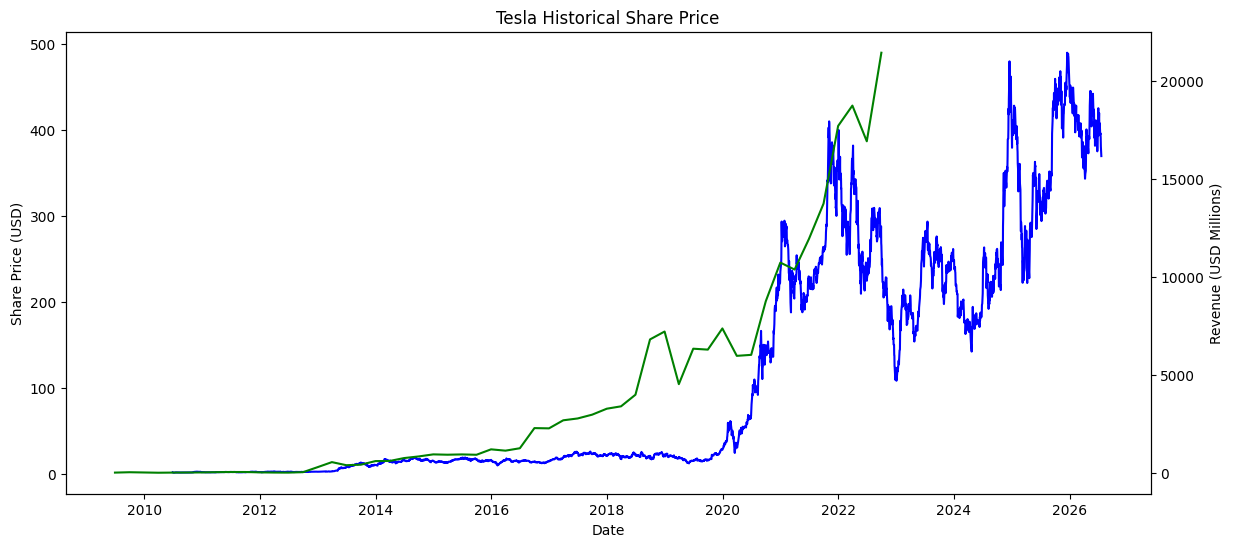

In [11]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):

    stock_data["Date"] = pd.to_datetime(stock_data["Date"])
    revenue_data["Date"] = pd.to_datetime(revenue_data["Date"])
    revenue_data["Revenue"] = revenue_data["Revenue"].astype(float)

    fig, ax1 = plt.subplots(figsize=(14,6))

    ax1.plot(stock_data["Date"], stock_data["Close"], color="blue")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Share Price (USD)")
    ax1.set_title(stock + " Historical Share Price")

    ax2 = ax1.twinx()
    ax2.plot(revenue_data["Date"], revenue_data["Revenue"], color="green")
    ax2.set_ylabel("Revenue (USD Millions)")

    plt.show()

make_graph(tesla_data, tesla_revenue, "Tesla")

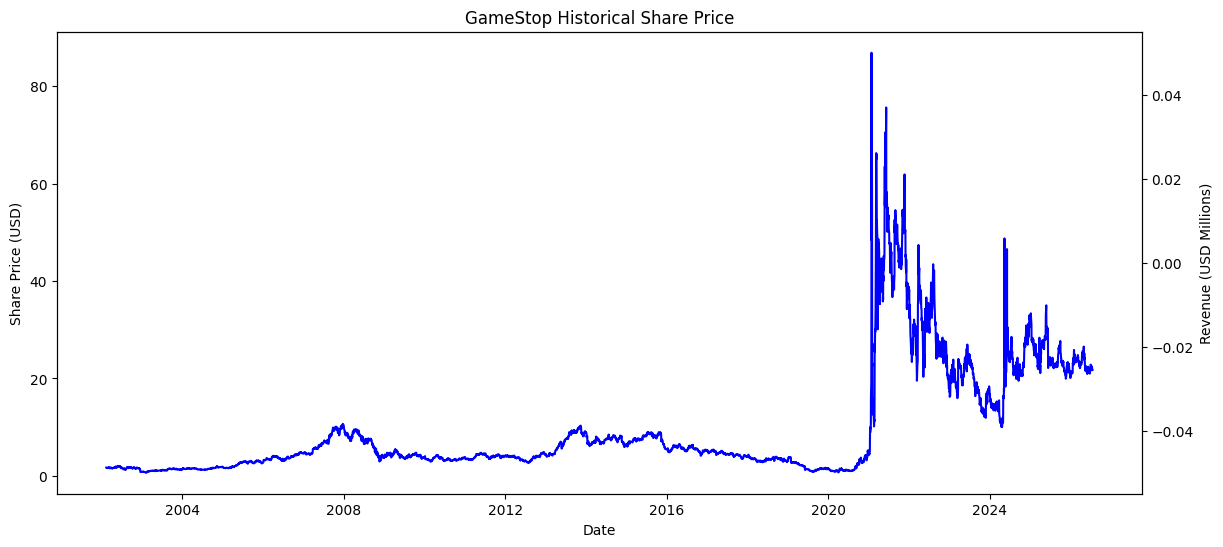

In [12]:
make_graph(gme_data, gme_revenue, "GameStop")

In [14]:
gme_revenue.tail()

,Date,Revenue
